# Deep Learning for Chest X-Ray Pneumonia Detection

Using a real-world Kaggle dataset of **5,863 chest X-rays**, I build a system that can tell if someone has pneumonia from their X-ray scan alone.

We go from raw data -> EDA -> scratch CNN -> ResNet18 transfer learning -> head-to-head comparison.

---
## Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import os, numpy as np, pandas as pd, random
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image as PILImage
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support, accuracy_score)

print(f'Device : {"CUDA " + torch.version.cuda if torch.cuda.is_available() else "CPU"}')

Device : CUDA 13.0


In [2]:
# All hyperparams in one place -- easy to tweak later
DATA_DIR    = '../data'  # path relative to this notebook
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_WORKERS = 0        
EPOCHS_CNN  = 10
EPOCHS_TL   = 10
LR          = 1e-3
SEED        = 42

# These are the exact stats ResNet was normalised with -- we reuse for consistency
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


---
## Exploratory Data Analysis


In [3]:
splits  = ['train', 'test']
classes = ['NORMAL', 'PNEUMONIA']

records = []
for split in splits:
    for cls in classes:
        folder = Path(DATA_DIR) / split / cls
        count  = len(list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png')))
        records.append({'Split': split, 'Class': cls, 'Count': count})

df_counts = pd.DataFrame(records)
df_counts

,Split,Class,Count
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,test,NORMAL,234
3,test,PNEUMONIA,390


In [4]:
# Grouped bar -- how many images per class per split?
fig = px.bar(
    df_counts,
    x='Split', y='Count', color='Class',
    barmode='group', text_auto=True,
    color_discrete_map={'NORMAL': '#2196F3', 'PNEUMONIA': '#F44336'},
    title='Dataset Split & Class Distribution'
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', font=dict(size=13))
fig.show()

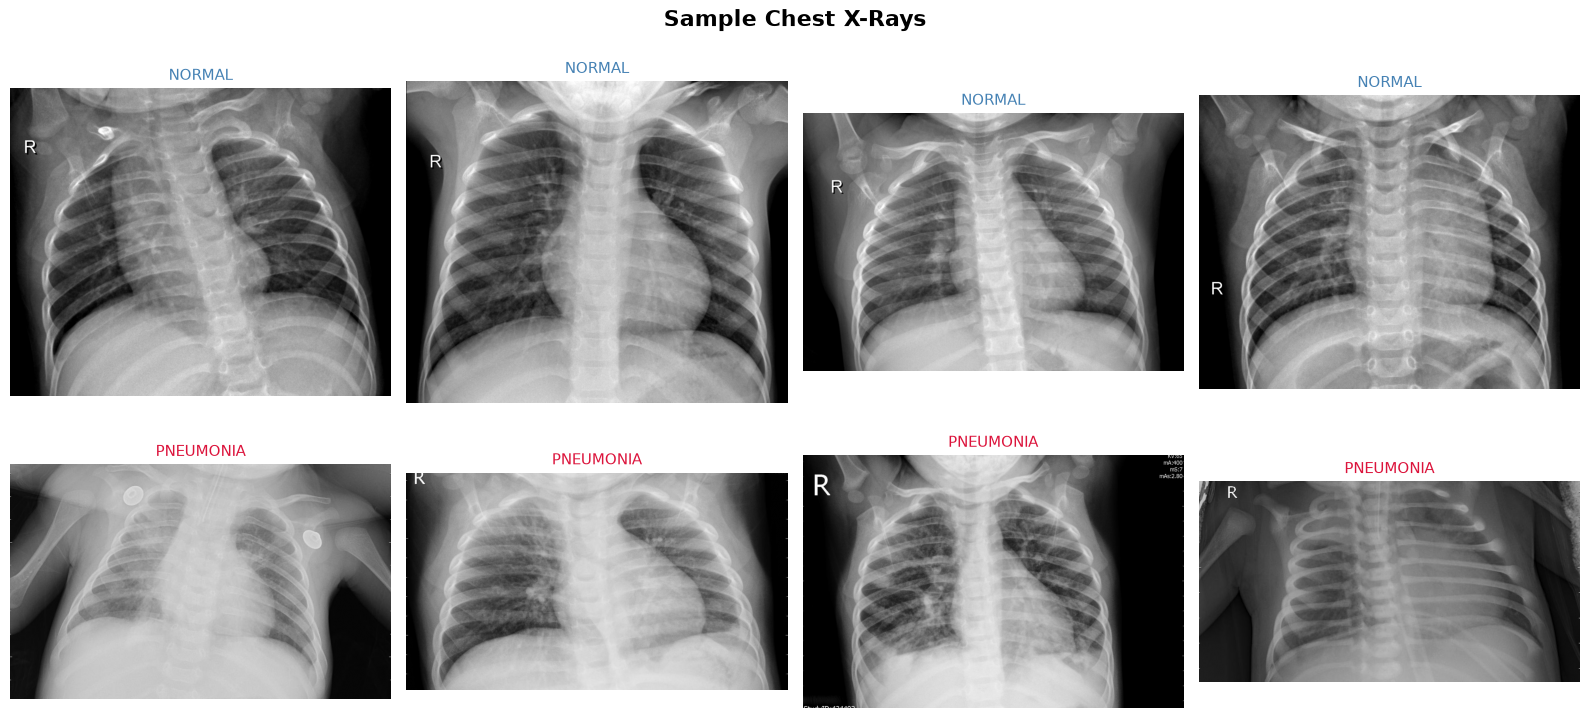

In [ ]:
# Sample X-rays --> what do NORMAL vs PNEUMONIA actually look like
# Normal lungs look clear; pneumonia lungs have cloudy patches
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Chest X-Rays', fontsize=16, fontweight='bold')

for row, cls in enumerate(classes):
    folder = Path(DATA_DIR) / 'train' / cls
    imgs   = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg'))
    sample = random.sample(imgs, 4)
    for col, path in enumerate(sample):
        img = mpimg.imread(path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=11,
            color='steelblue' if cls == 'NORMAL' else 'crimson')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

---
## Data Pipeline

Training gets heavy random augmentations every epoch. Val/Test gets only clean center-crop -- we never augment at eval time or the metrics will be wrong.

In [ ]:
# Training: maximum randomness so the model can't memorize exact images

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMAGE_SIZE),   # random crop -- every epoch looks slightly different
    transforms.RandomHorizontalFlip(),           # X-rays can be flipped safely (left <-> right)
    transforms.RandomRotation(10),               # slight tilt -- real scans aren't perfectly aligned
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # simulate scanner exposure variation
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),  # normalize to same stats ResNet expects
])


# Val/Test: no randomness at all -- just clean, deterministic preprocessing

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

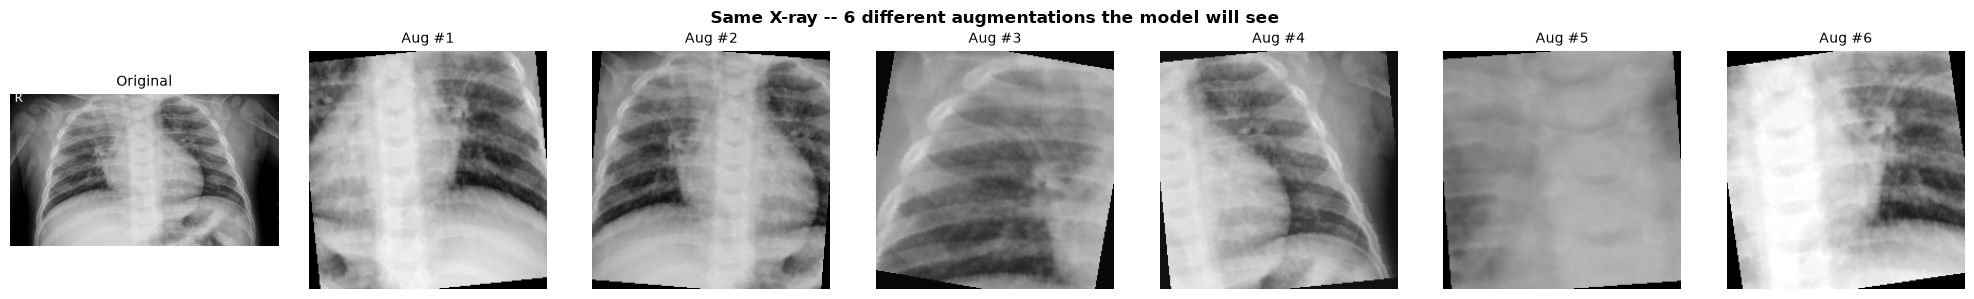

In [ ]:
# Show what augmentation actually does -- same image, 6 different-looking versions

sample_img_path = random.choice(
    list((Path(DATA_DIR) / 'train' / 'PNEUMONIA').glob('*.jpeg'))
)
original = PILImage.open(sample_img_path).convert('RGB')    
aug_versions = [train_transforms(original) for _ in range(6)]

fig, axes = plt.subplots(1, 7, figsize=(20, 3))
axes[0].imshow(original)
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

for i, t in enumerate(aug_versions, 1):
    # Reverse the normalisation so the image is actually visible
    img_disp = t.permute(1, 2, 0).numpy()
    img_disp = img_disp * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_disp = np.clip(img_disp, 0, 1)
    axes[i].imshow(img_disp)
    axes[i].set_title(f'Aug #{i}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Same X-ray -- 6 different augmentations the model will see', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Load datasets and do an 80/20 train/val split

full_train_ds = datasets.ImageFolder(Path(DATA_DIR) / 'train', transform=train_transforms)
test_ds       = datasets.ImageFolder(Path(DATA_DIR) / 'test',  transform=eval_transforms)
CLASS_NAMES   = full_train_ds.classes   # ['NORMAL', 'PNEUMONIA']

train_size = int(0.8 * len(full_train_ds))
val_size   = len(full_train_ds) - train_size
generator  = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size], generator=generator)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Classes: {CLASS_NAMES}')

Train: 4172 | Val: 1044 | Test: 624
Classes: ['NORMAL', 'PNEUMONIA']


In [9]:
# WeightedRandomSampler -- the class imbalance fix
# We have ~3x more pneumonia images than normal.
# Instead of duplicating files on disk, we tell PyTorch to pick the minority class MORE often per batch.

targets      = [full_train_ds.targets[i] for i in train_ds.indices]
class_counts = [targets.count(i) for i in range(len(CLASS_NAMES))]
print('Training class counts:', dict(zip(CLASS_NAMES, class_counts)))

# Inverse frequency: rarer class gets a higher sample weight
class_weights  = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = torch.tensor([class_weights[t] for t in targets])

# Every batch now gets roughly 50/50 Normal:Pneumonia
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=NUM_WORKERS)
print('DataLoaders ready')

Training class counts: {'NORMAL': 1058, 'PNEUMONIA': 3114}
DataLoaders ready


In [26]:
# Quick sanity check -- confirm batch is balanced after WeightedRandomSampler
images, labels = next(iter(train_loader))
unique, counts = torch.unique(labels, return_counts=True)
print(f'Batch shape: {images.shape}')
print(f'Batch class balance: {dict(zip(CLASS_NAMES, counts.tolist()))}')
print('Batch is balanced!' if abs(counts[0].item() - counts[1].item()) < 8 else 'Imbalanced batch')

Batch shape: torch.Size([32, 3, 224, 224])
Batch class balance: {'NORMAL': 16, 'PNEUMONIA': 16}
Batch is balanced!


---
## Approach A -- Custom CNN from Scratch

Let's first try building a simple ConvNet ourselves and see how far we get with 5.8K images and zero borrowed knowledge from ImageNet.

In [11]:
class PneumoniaCNN(nn.Module):
    """
    Classic ConvNet: Conv -> BN -> ReLU -> Pool, stacked 4 times,
    then flatten and classify with two fully connected layers.
    """
    def __init__(self, num_classes=2):
        super().__init__()

        # Feature extractor -- each block: learn features -> stabilise -> halve spatial size
        self.features = nn.Sequential(
            # Block 1: 224x224 -> 112x112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 3 RGB channels in, 32 feature maps out
            nn.BatchNorm2d(32),                            # keeps activations stable during training
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # halve height and width

            # Block 2: 112x112 -> 56x56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 56x56 -> 28x28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 28x28 -> 14x14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # AdaptiveAvgPool forces output to 7x7 regardless of input size
        self.pool = nn.AdaptiveAvgPool2d((7, 7))

        # Classifier -- after pool: 256 channels x 7x7 = 12544 values per image
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),                   # randomly zero 40% of neurons -- forces redundancy
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),       # final: 2 logits (Normal vs Pneumonia)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)   # flatten: [batch, 256, 7, 7] -> [batch, 12544]
        x = self.classifier(x)
        return x


cnn_model        = PneumoniaCNN(num_classes=2)
total_params     = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Custom CNN -- Total params: {total_params:,} | Trainable: {trainable_params:,}')

Custom CNN -- Total params: 6,813,442 | Trainable: 6,813,442


In [ ]:
def train_loop(model, train_loader, val_loader, epochs, lr, label='Model'):
    """
    Reusable training loop for both the scratch CNN and ResNet.
    Returns the best-checkpoint model + history dict.
    """
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()                        # standard multi-class loss
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # CosineAnnealing: starts high for exploration, smoothly decays to near zero
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    save_path    = f'{label.lower().replace(" ", "_")}_best.pth'

    print(f'\nTraining [{label}] on {DEVICE} for {epochs} epochs...')

        #  TRAINING 
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()           # clear old gradients
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()                 # compute gradients via backprop
            optimizer.step()                # update weights
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        #   VALIDATE 
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():   # no gradients needed -- we're just measuring
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total
        scheduler.step()   # nudge the learning rate down along the cosine curve

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)   # snapshot the best checkpoint

        print(
            f'  Epoch {epoch+1:02d}/{epochs} | '
            f'train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | '
            f'val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}'
        )

    print(f'\nBest val accuracy [{label}]: {best_val_acc:.4f}')
    model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    return model, history

In [13]:
cnn_model, cnn_history = train_loop(
    cnn_model, train_loader, val_loader,
    epochs=EPOCHS_CNN, lr=LR, label='Custom CNN'
)


Training [Custom CNN] on cuda for 10 epochs...
  Epoch 01/10 | train_loss: 0.8863 | train_acc: 0.6673 | val_loss: 0.4986 | val_acc: 0.7644
  Epoch 02/10 | train_loss: 0.5276 | train_acc: 0.7517 | val_loss: 0.4284 | val_acc: 0.8008
  Epoch 03/10 | train_loss: 0.5119 | train_acc: 0.7605 | val_loss: 0.5546 | val_acc: 0.7299
  Epoch 04/10 | train_loss: 0.4778 | train_acc: 0.7800 | val_loss: 0.3862 | val_acc: 0.8400
  Epoch 05/10 | train_loss: 0.4701 | train_acc: 0.7898 | val_loss: 0.4184 | val_acc: 0.8065
  Epoch 06/10 | train_loss: 0.4428 | train_acc: 0.8070 | val_loss: 0.4245 | val_acc: 0.8094
  Epoch 07/10 | train_loss: 0.4203 | train_acc: 0.8150 | val_loss: 0.3289 | val_acc: 0.8534
  Epoch 08/10 | train_loss: 0.3907 | train_acc: 0.8346 | val_loss: 0.3376 | val_acc: 0.8515
  Epoch 09/10 | train_loss: 0.3773 | train_acc: 0.8437 | val_loss: 0.3155 | val_acc: 0.8630
  Epoch 10/10 | train_loss: 0.3643 | train_acc: 0.8514 | val_loss: 0.3686 | val_acc: 0.8410

Best val accuracy [Custom CNN]:

In [14]:
def plot_training_curves(history, title='Training Curves'):
    """Interactive Plotly loss + accuracy curves -- hover to see exact values."""
    epochs = list(range(1, len(history['train_loss']) + 1))

    fig = make_subplots(rows=1, cols=2, subplot_titles=['Loss', 'Accuracy'])

    fig.add_trace(go.Scatter(x=epochs, y=history['train_loss'], name='Train Loss',
                             line=dict(color='royalblue', width=2)), row=1, col=1)
    fig.add_trace(go.Scatter(x=epochs, y=history['val_loss'], name='Val Loss',
                             line=dict(color='tomato', width=2, dash='dash')), row=1, col=1)
    fig.add_trace(go.Scatter(x=epochs, y=history['train_acc'], name='Train Acc',
                             line=dict(color='royalblue', width=2)), row=1, col=2)
    fig.add_trace(go.Scatter(x=epochs, y=history['val_acc'], name='Val Acc',
                             line=dict(color='tomato', width=2, dash='dash')), row=1, col=2)

    fig.update_layout(title_text=title, plot_bgcolor='white', paper_bgcolor='white', height=400)
    fig.update_xaxes(title_text='Epoch')
    fig.show()


plot_training_curves(cnn_history, title='Custom CNN -- Training Curves')

In [15]:
def evaluate_and_report(model, test_loader, class_names, label='Model'):
    """Run inference on the test set, print classification report, return preds + labels."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(DEVICE))
            preds   = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    print(f'\n{"="*60}\n  {label} -- Classification Report\n{"="*60}')
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    return all_preds, all_labels


def plot_cm_plotly(y_true, y_pred, class_names, title='Confusion Matrix'):
    """Interactive confusion matrix -- shows raw count + normalised recall in each cell."""
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Show both raw count and recall fraction in each cell
    text = [
        [f'{cm[i,j]}<br>({cm_norm[i,j]:.2f})' for j in range(len(class_names))]
        for i in range(len(class_names))
    ]

    fig = px.imshow(
        cm_norm, x=class_names, y=class_names,
        color_continuous_scale='Blues',
        labels=dict(x='Predicted', y='Actual', color='Recall'),
        title=title, zmin=0, zmax=1
    )
    fig.update_traces(text=text, texttemplate='%{text}', textfont={'size': 14})
    fig.update_layout(height=450)
    fig.show()

In [16]:
cnn_preds, cnn_labels = evaluate_and_report(cnn_model, test_loader, CLASS_NAMES, label='Custom CNN')
plot_cm_plotly(cnn_labels, cnn_preds, CLASS_NAMES, title='Custom CNN -- Confusion Matrix')


  Custom CNN -- Classification Report
              precision    recall  f1-score   support

      NORMAL     0.7961    0.5171    0.6269       234
   PNEUMONIA     0.7606    0.9205    0.8329       390

    accuracy                         0.7692       624
   macro avg     0.7783    0.7188    0.7299       624
weighted avg     0.7739    0.7692    0.7557       624



---
## Approach B -- Transfer Learning with ResNet18

ResNet18 has already seen **1.2 million images** from ImageNet. Its convolutional layers are expert at detecting edges, textures, and shapes. We freeze those layers and just swap in a new classification head for our 2-class problem.

In [ ]:
# Load ResNet18 with pretrained ImageNet weights
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze everything -- don't mess with the knowledge it already has
for param in resnet.parameters():
    param.requires_grad = False

# The final FC layer originally has 1000 outputs (ImageNet classes)
# We replace it: Dropout -> Linear(512, 2) for our binary classification

in_features = resnet.fc.in_features   # 512 for ResNet18
resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 2),
)

total     = sum(p.numel() for p in resnet.parameters())
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'ResNet18 -- Total: {total:,} | Trainable: {trainable:,}')
print(f'Only {trainable/total*100:.2f}% of the network is actually being trained!')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:11<00:00, 4.03MB/s]

ResNet18 -- Total: 11,177,538 | Trainable: 1,026
Only 0.01% of the network is actually being trained!


In [18]:
# Show frozen vs trainable param counts
total     = sum(p.numel() for p in resnet.parameters())
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'ResNet18 -- Total params : {total:,}')
print(f'           Trainable     : {trainable:,}  ({trainable/total*100:.1f}%)')
print(f'           Frozen        : {total-trainable:,}  ({(total-trainable)/total*100:.1f}%)')

ResNet18 -- Total params : 11,177,538
           Trainable     : 1,026  (0.0%)
           Frozen        : 11,176,512  (100.0%)


In [19]:
resnet, resnet_history = train_loop(
    resnet, train_loader, val_loader,
    epochs=EPOCHS_TL, lr=LR, label='ResNet18 Transfer'
)


Training [ResNet18 Transfer] on cuda for 10 epochs...
  Epoch 01/10 | train_loss: 0.5635 | train_acc: 0.6997 | val_loss: 0.3963 | val_acc: 0.8333
  Epoch 02/10 | train_loss: 0.4625 | train_acc: 0.7850 | val_loss: 0.3805 | val_acc: 0.8410
  Epoch 03/10 | train_loss: 0.4364 | train_acc: 0.7975 | val_loss: 0.3670 | val_acc: 0.8496
  Epoch 04/10 | train_loss: 0.4429 | train_acc: 0.7953 | val_loss: 0.3682 | val_acc: 0.8458
  Epoch 05/10 | train_loss: 0.4382 | train_acc: 0.7972 | val_loss: 0.4273 | val_acc: 0.8190
  Epoch 06/10 | train_loss: 0.4217 | train_acc: 0.8176 | val_loss: 0.4578 | val_acc: 0.8027
  Epoch 07/10 | train_loss: 0.4334 | train_acc: 0.8094 | val_loss: 0.3852 | val_acc: 0.8352
  Epoch 08/10 | train_loss: 0.4146 | train_acc: 0.8104 | val_loss: 0.3643 | val_acc: 0.8515
  Epoch 09/10 | train_loss: 0.4201 | train_acc: 0.8226 | val_loss: 0.3579 | val_acc: 0.8534
  Epoch 10/10 | train_loss: 0.4066 | train_acc: 0.8209 | val_loss: 0.3121 | val_acc: 0.8860

Best val accuracy [ResNe

In [20]:
plot_training_curves(resnet_history, title='ResNet18 Transfer Learning -- Training Curves')

In [21]:
resnet_preds, resnet_labels = evaluate_and_report(resnet, test_loader, CLASS_NAMES, label='ResNet18 TL')
plot_cm_plotly(resnet_labels, resnet_preds, CLASS_NAMES, title='ResNet18 TL -- Confusion Matrix')


  ResNet18 TL -- Classification Report
              precision    recall  f1-score   support

      NORMAL     0.7224    0.8675    0.7883       234
   PNEUMONIA     0.9096    0.8000    0.8513       390

    accuracy                         0.8253       624
   macro avg     0.8160    0.8338    0.8198       624
weighted avg     0.8394    0.8253    0.8277       624



---
## Head-to-Head Comparison

Let's stack both models side-by-side and see the actual difference pretrained weights make.

In [22]:
def get_metrics(y_true, y_pred):
    """Extract key classification metrics into a dict."""
    acc  = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred)
    return {
        'Accuracy':            round(acc,  4),
        'Normal Precision':    round(p[0], 4),
        'Normal Recall':       round(r[0], 4),
        'Normal F1':           round(f[0], 4),
        'Pneumonia Precision': round(p[1], 4),
        'Pneumonia Recall':    round(r[1], 4),   # most clinically important
        'Pneumonia F1':        round(f[1], 4),
    }


cnn_metrics    = get_metrics(cnn_labels,    cnn_preds)
resnet_metrics = get_metrics(resnet_labels, resnet_preds)

df_compare = pd.DataFrame({
    'Metric':      list(cnn_metrics.keys()),
    'Custom CNN':  list(cnn_metrics.values()),
    'ResNet18 TL': list(resnet_metrics.values()),
})
df_compare['Delta (ResNet-CNN)'] = (df_compare['ResNet18 TL'] - df_compare['Custom CNN']).round(4)
df_compare

,Metric,Custom CNN,ResNet18 TL,Delta (ResNet-CNN)
0,Accuracy,0.7692,0.8253,0.0561
1,Normal Precision,0.7961,0.7224,-0.0737
2,Normal Recall,0.5171,0.8675,0.3504
3,Normal F1,0.6269,0.7883,0.1614
4,Pneumonia Precision,0.7606,0.9096,0.1490
5,Pneumonia Recall,0.9205,0.8000,-0.1205
6,Pneumonia F1,0.8329,0.8513,0.0184


In [23]:
# Grouped bar -- all metrics side by side
df_melt = df_compare[['Metric', 'Custom CNN', 'ResNet18 TL']].melt(
    id_vars='Metric', var_name='Model', value_name='Score'
)

fig = px.bar(
    df_melt,
    x='Metric', y='Score', color='Model', barmode='group',
    text_auto=True,
    color_discrete_map={'Custom CNN': '#FF7043', 'ResNet18 TL': '#42A5F5'},
    title='Custom CNN vs ResNet18 Transfer Learning -- All Metrics'
)
fig.update_yaxes(range=[0, 1.1])
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', xaxis_tickangle=-30)
fig.show()

In [ ]:
# Overlaid validation curves -- how fast did each model learn?

e = list(range(1, EPOCHS_CNN + 1))

fig = make_subplots(rows=1, cols=2, subplot_titles=['Val Loss', 'Val Accuracy'])

fig.add_trace(go.Scatter(x=e, y=cnn_history['val_loss'],
              name='CNN', line=dict(color='#FF7043', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=e, y=resnet_history['val_loss'],
              name='ResNet18', line=dict(color='#42A5F5', width=2, dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=e, y=cnn_history['val_acc'],
              name='CNN', line=dict(color='#FF7043', width=2), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=e, y=resnet_history['val_acc'],
              name='ResNet18', line=dict(color='#42A5F5', width=2, dash='dash'), showlegend=False), row=1, col=2)

fig.update_layout(
    title_text='Val Curves -- CNN vs ResNet18',
    plot_bgcolor='white', paper_bgcolor='white', height=400
)
fig.update_xaxes(title_text='Epoch')
fig.show()

In [25]:
# Clean summary table with delta column
print(f'{"="*65}')
print(f'  {"Metric":<28} {"Custom CNN":>12} {"ResNet18 TL":>12}')
print(f'{"="*65}')
for m in cnn_metrics:
    delta = resnet_metrics[m] - cnn_metrics[m]
    arrow = '^' if delta > 0 else ('v' if delta < 0 else '=')
    print(f'  {m:<28} {cnn_metrics[m]:>12.4f} {resnet_metrics[m]:>12.4f}  {arrow} {abs(delta):.4f}')
print(f'{"="*65}')

  Metric                         Custom CNN  ResNet18 TL
  Accuracy                           0.7692       0.8253  ^ 0.0561
  Normal Precision                   0.7961       0.7224  v 0.0737
  Normal Recall                      0.5171       0.8675  ^ 0.3504
  Normal F1                          0.6269       0.7883  ^ 0.1614
  Pneumonia Precision                0.7606       0.9096  ^ 0.1490
  Pneumonia Recall                   0.9205       0.8000  v 0.1205
  Pneumonia F1                       0.8329       0.8513  ^ 0.0184


---
## Conclusion

**Why ResNet wins with only 5.8K images:** A scratch CNN has to learn *everything* from scratch -- edges, textures, shapes. ResNet already has all of that baked in from 1.2M ImageNet images. We're just teaching it the final decision step.

**Why Pneumonia Recall is the star metric:** Missing a pneumonia case (False Negative) means a sick patient goes home untreated. A false alarm (False Positive) just means an extra doctor check -- far less harmful.

**Why Cosine Annealing LR:** A flat learning rate either overshoots or stalls. CosineAnnealingLR starts exploring fast and gradually settles -- no manual decay schedule, no sharp drops.